# 05 — PM2.5 Level Classification

Binary and multi-class classification of daily PM2.5 exceedance levels.

**Two classification targets:**
- **Binary** — WHO 24h threshold exceedance: PM2.5 > 25 µg/m³ (yes/no)
- **3-class** — Low / Moderate / High based on fixed µg/m³ thresholds

**Models:** Logistic Regression · Random Forest · LightGBM · XGBoost

**Split:** train 2016–2018, test 2019 (strict temporal)  
**CV:** `TimeSeriesSplit` + `RandomizedSearchCV`  
**Scoring:** binary = AUC · 3-class = F1-macro  
**Data:** `all_data.csv` (daily, all stations)

## 0. Imports & configuration

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings("ignore")
np.random.seed(42)

# Classification targets
WHO_THRESHOLD = 25.0
CLASS_BINS    = [0, 15, 35, np.inf]
CLASS_LABELS  = ["Low", "Moderate", "High"]

# Split
TRAIN_YEARS = [2016, 2017, 2018]
TEST_YEAR   = 2019

# CV
N_CV_SPLITS   = 5
N_ITER_SEARCH = 20 # For quick testing; increase to 10-15 for final runs
RANDOM_STATE  = 42

print("Configuration loaded.")
print(f"  Binary threshold : PM2.5 > {WHO_THRESHOLD} µg/m3")
print(f"  3-class bins     : {CLASS_BINS} -> {CLASS_LABELS}")
print(f"  CV folds         : {N_CV_SPLITS} (TimeSeriesSplit)")
print(f"  Search iters     : {N_ITER_SEARCH} per model")


Configuration loaded.
  Binary threshold : PM2.5 > 25.0 µg/m3
  3-class bins     : [0, 15, 35, inf] -> ['Low', 'Moderate', 'High']
  CV folds         : 5 (TimeSeriesSplit)
  Search iters     : 1 per model


## 1. Load data

In [37]:
df_raw = pd.read_csv("all_data.csv")
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if "Unnamed" in c], errors="ignore")
df_raw["date"] = pd.to_datetime(df_raw["date"])
if df_raw["date"].dt.tz is not None:
    df_raw["date"] = df_raw["date"].dt.tz_localize(None)
df_raw = df_raw.dropna(subset=["pm25"])
df_raw = df_raw.sort_values(["stacja", "date"]).reset_index(drop=True)

print(f"Loaded: {df_raw.shape[0]:,} rows, {df_raw['stacja'].nunique()} stations")
print(f"Date range: {df_raw['date'].min().date()} - {df_raw['date'].max().date()}")
print(f"PM2.5: mean={df_raw['pm25'].mean():.1f}  median={df_raw['pm25'].median():.1f}  max={df_raw['pm25'].max():.1f} ug/m3")


Loaded: 48,017 rows, 45 stations
Date range: 2017-01-01 - 2019-12-31
PM2.5: mean=21.7  median=15.6  max=292.0 ug/m3


## 2. Create classification targets

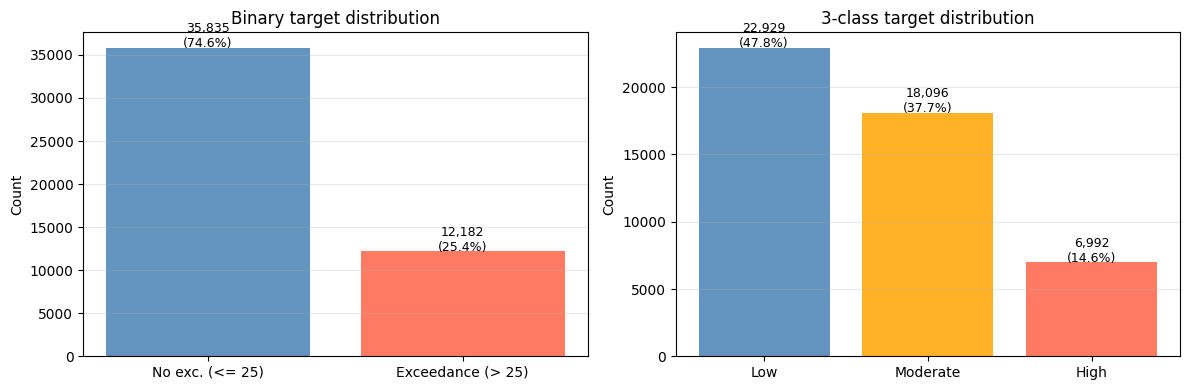

In [38]:
df_raw["target_binary"] = (df_raw["pm25"] > WHO_THRESHOLD).astype(int)
#df_raw["target_3class"] = pd.cut(
#    df_raw["pm25"], bins=CLASS_BINS, labels=CLASS_LABELS, right=True
#)
# Zmień to w komórce z definicją celu (target)
df_raw["target_3class"] = pd.cut(
    df_raw["pm25"], 
    bins=CLASS_BINS, 
    labels=CLASS_LABELS, 
    right=True,
    include_lowest=True  # <--- Dodaj to!
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
counts_bin = df_raw["target_binary"].value_counts().sort_index()
ax.bar(["No exc. (<= 25)", "Exceedance (> 25)"], counts_bin.values,
       color=["steelblue", "tomato"], alpha=0.85)
for i, v in enumerate(counts_bin.values):
    ax.text(i, v + 50, f"{v:,}\n({100*v/len(df_raw):.1f}%)",
            ha="center", fontsize=9)
ax.set_title("Binary target distribution")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
counts_3 = df_raw["target_3class"].value_counts()[CLASS_LABELS]
ax.bar(CLASS_LABELS, counts_3.values,
       color=["steelblue", "orange", "tomato"], alpha=0.85)
for i, v in enumerate(counts_3.values):
    ax.text(i, v + 50, f"{v:,}\n({100*v/len(df_raw):.1f}%)",
            ha="center", fontsize=9)
ax.set_title("3-class target distribution")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plot_cls_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Feature engineering

In [39]:
# Cyclic calendar features
df_raw["month_sin"]   = np.sin(2 * np.pi * df_raw["date"].dt.month     / 12)
df_raw["month_cos"]   = np.cos(2 * np.pi * df_raw["date"].dt.month     / 12)
df_raw["yearday_sin"] = np.sin(2 * np.pi * df_raw["date"].dt.dayofyear / 365)
df_raw["yearday_cos"] = np.cos(2 * np.pi * df_raw["date"].dt.dayofyear / 365)

WEATHER_FEATURES = [
    "temperature_2m_min", "wind_speed_10m_max", "wind_speed_10m_mean",
    "wind_direction_10m_dominant", "cloud_cover_mean", "surface_pressure_mean",
    "dew_point_2m_mean", "relative_humidity_2m_min", "boundary_layer_height",
]
STATION_FEATURES = [
    "lat", "lon", "elevation",
    "nearest_road_dist_m", "total_road_length_km", "building_count",
    "population", "built_up_surface", "built_up_volume",
]
CALENDAR_FEATURES = ["month_sin", "month_cos", "yearday_sin", "yearday_cos"]

# Lag features -- grouped by station to prevent cross-station leakage
LAG_FEATURES = [
    "temperature_2m_min", "wind_speed_10m_max", "cloud_cover_mean",
    "surface_pressure_mean", "dew_point_2m_mean", "boundary_layer_height",
]
LAG_DAYS = [1, 2]

df = df_raw.copy().sort_values(["stacja", "date"])
for col in LAG_FEATURES:
    if col not in df.columns:
        continue
    for lag in LAG_DAYS:
        df[f"{col}_lag{lag}"] = df.groupby("stacja")[col].shift(lag)

lag_check = [f"{c}_lag{max(LAG_DAYS)}" for c in LAG_FEATURES if c in df.columns]
df = df.dropna(subset=lag_check)

LAG_COLS     = [c for c in df.columns if "_lag" in c]
FEATURE_COLS = [
    f for f in WEATHER_FEATURES + STATION_FEATURES + CALENDAR_FEATURES + LAG_COLS
    if f in df.columns
]

print(f"After feature engineering: {df.shape[0]:,} rows")
print(f"Features: {len(FEATURE_COLS)} total")
print(f"  weather={len([f for f in WEATHER_FEATURES if f in df.columns])}"
      f"  station={len([f for f in STATION_FEATURES if f in df.columns])}"
      f"  calendar={len(CALENDAR_FEATURES)}  lag={len(LAG_COLS)}")


After feature engineering: 47,927 rows
Features: 34 total
  weather=9  station=9  calendar=4  lag=12


## 4. Train / test split

Strict temporal split: 2016-2018 train, 2019 test.  
Data sorted by date so `TimeSeriesSplit` folds expand chronologically.

In [40]:
'''
train = df[df["date"].dt.year.isin(TRAIN_YEARS)].sort_values("date")
test  = df[df["date"].dt.year == TEST_YEAR].sort_values("date")

X_train = train[FEATURE_COLS]
X_test  = test[FEATURE_COLS]

y_train_bin = train["target_binary"]
y_test_bin  = test["target_binary"]
y_train_3   = train["target_3class"]
y_test_3    = test["target_3class"]

print(f"Train: {len(train):,} samples  ({train['date'].min().date()} - {train['date'].max().date()})")
print(f"Test : {len(test):,} samples   ({test['date'].min().date()} - {test['date'].max().date()})")
print()
print("Binary class balance (train):")
print(y_train_bin.value_counts(normalize=True).round(3).to_string())
print()
print("3-class balance (train):")
print(y_train_3.value_counts(normalize=True)[CLASS_LABELS].round(3).to_string())
'''


'\ntrain = df[df["date"].dt.year.isin(TRAIN_YEARS)].sort_values("date")\ntest  = df[df["date"].dt.year == TEST_YEAR].sort_values("date")\n\nX_train = train[FEATURE_COLS]\nX_test  = test[FEATURE_COLS]\n\ny_train_bin = train["target_binary"]\ny_test_bin  = test["target_binary"]\ny_train_3   = train["target_3class"]\ny_test_3    = test["target_3class"]\n\nprint(f"Train: {len(train):,} samples  ({train[\'date\'].min().date()} - {train[\'date\'].max().date()})")\nprint(f"Test : {len(test):,} samples   ({test[\'date\'].min().date()} - {test[\'date\'].max().date()})")\nprint()\nprint("Binary class balance (train):")\nprint(y_train_bin.value_counts(normalize=True).round(3).to_string())\nprint()\nprint("3-class balance (train):")\nprint(y_train_3.value_counts(normalize=True)[CLASS_LABELS].round(3).to_string())\n'

In [41]:
# A. Podział na train i test (surowe dane)
train = df[df["date"].dt.year.isin(TRAIN_YEARS)].sort_values("date")
test  = df[df["date"].dt.year == TEST_YEAR].sort_values("date")

X_train = train[FEATURE_COLS]
X_test  = test[FEATURE_COLS]

# B. Przygotowanie targetów
y_train_bin = train["target_binary"]
y_test_bin  = test["target_binary"]

# C. MAPOWANIE 3-CLASS (Kluczowy moment)
# Tworzymy mapę: {'Low': 0, 'Moderate': 1, 'High': 2}
class_map = {label: i for i, label in enumerate(CLASS_LABELS)}

# Pobieramy wartości bezpośrednio z przefiltrowanych ramek train/test i mapujemy
y_train_3 = train["target_3class"].map(class_map).astype(int)
y_test_3  = test["target_3class"].map(class_map).astype(int)

# D. WYŚWIETLANIE (Sprawdzamy czy działa)
print(f"Train samples: {len(X_train):,}")
print(f"Test samples : {len(X_test):,}")

print("\nBinary class balance (train):")
bin_labels = {0: "No exc. (<=25)", 1: "Exceedance (>25)"}
print(y_train_bin.value_counts(normalize=True).rename(index=bin_labels).round(3))

print("\n3-class balance (train):")
# Odwracamy mapę do wyświetlenia: {0: 'Low', 1: 'Moderate', 2: 'High'}
inv_map = {v: k for k, v in class_map.items()}
print(y_train_3.value_counts(normalize=True).rename(index=inv_map).round(3))

Train samples: 31,847
Test samples : 16,080

Binary class balance (train):
target_binary
No exc. (<=25)      0.724
Exceedance (>25)    0.276
Name: proportion, dtype: float64

3-class balance (train):
target_3class
Low         0.450
Moderate    0.385
High        0.165
Name: proportion, dtype: float64


## 5. Model factory

All models: `Pipeline(StandardScaler -> classifier)` +  
`RandomizedSearchCV` with `TimeSeriesSplit` (identical scheme to notebooks 02/03).  
Tree models use `class_weight='balanced'` to handle class imbalance.

In [ ]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)


def make_searches(task: str) -> dict:
    """
    Return {model_name: RandomizedSearchCV} for the given task.
    task: 'binary'  -> scoring = roc_auc
          '3class'  -> scoring = f1_macro
    """
    scoring = "roc_auc" if task == "binary" else "f1_macro"

    configs = {
        "Logistic Regression": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  LogisticRegression(
                    multi_class="multinomial", solver="saga",
                    max_iter=1000, random_state=RANDOM_STATE)),
            ]),
            {
                "model__C":       loguniform(1e-3, 100),
                "model__penalty": ["l1", "l2"],
            },
        ),
        "Random Forest": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  RandomForestClassifier(
                    random_state=RANDOM_STATE, n_jobs=-1,
                    class_weight="balanced")),
            ]),
            {
                "model__n_estimators":      randint(100, 300), #should be 500 for final runs
                "model__max_depth":         [None, 10, 20, 30],
                "model__min_samples_split": randint(2, 20),
                "model__min_samples_leaf":  randint(1, 10),
                "model__max_features":      ["sqrt", "log2", 0.5],
            },
        ),
        "LightGBM": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  lgb.LGBMClassifier(
                    random_state=RANDOM_STATE, verbose=-1,
                    class_weight="balanced")),
            ]),
            {
                "model__n_estimators":      randint(100, 300), #should be 500 for final runs
                "model__max_depth":         randint(3, 12),
                "model__learning_rate":     loguniform(0.01, 0.3),
                "model__num_leaves":        randint(15, 100),
                "model__min_child_samples": randint(5, 50),
                "model__subsample":         uniform(0.6, 0.4),
                "model__colsample_bytree":  uniform(0.6, 0.4),
            },
        ),
        "XGBoost": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model",  xgb.XGBClassifier(
                    random_state=RANDOM_STATE, verbosity=0,
                    tree_method="hist", eval_metric="logloss")),
            ]),
            {
                "model__n_estimators":     randint(100, 300), #should be 500 for final runs
                "model__max_depth":        randint(3, 10),
                "model__learning_rate":    loguniform(0.01, 0.3),
                "model__subsample":        uniform(0.6, 0.4),
                "model__colsample_bytree": uniform(0.6, 0.4),
                "model__reg_alpha":        loguniform(1e-3, 10),
                "model__reg_lambda":       loguniform(1e-3, 10),
            },
        ),
    }

    return {
        name: RandomizedSearchCV(
            estimator           = pipeline,
            param_distributions = param_dist,
            n_iter              = N_ITER_SEARCH,
            cv                  = tscv,
            scoring             = scoring,
            n_jobs              = -1,
            random_state        = RANDOM_STATE,
            verbose             = 1,
            refit               = True,
        )
        for name, (pipeline, param_dist) in configs.items()
    }


print("Model factory ready.")
print("  Binary CV scoring  : roc_auc")
print("  3-class CV scoring : f1_macro")


Model factory ready.
  Binary CV scoring  : roc_auc
  3-class CV scoring : f1_macro


## 6. Binary classification — training

In [43]:
print("=" * 55)
print("BINARY CLASSIFICATION  (PM2.5 > 25 ug/m3)")
print("=" * 55)

searches_bin = make_searches("binary")
results_bin  = {}

for name, search in searches_bin.items():
    print(f"\nFitting {name}...")
    search.fit(X_train, y_train_bin)
    y_pred  = search.predict(X_test)
    y_proba = (
        search.predict_proba(X_test)[:, 1]
        if hasattr(search.best_estimator_, "predict_proba") else None
    )
    auc = roc_auc_score(y_test_bin, y_proba) if y_proba is not None else None
    results_bin[name] = dict(
        search=search, y_pred=y_pred, y_proba=y_proba,
        acc=accuracy_score(y_test_bin, y_pred),
        f1=f1_score(y_test_bin, y_pred),
        auc=auc, cv_score=search.best_score_,
    )
    print(f"  CV AUC : {search.best_score_:.4f}")
    print(f"  Test   : Acc={results_bin[name]['acc']:.4f}  "
          f"F1={results_bin[name]['f1']:.4f}  AUC={auc:.4f}")


BINARY CLASSIFICATION  (PM2.5 > 25 ug/m3)

Fitting Logistic Regression...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


  CV AUC : 0.8217
  Test   : Acc=0.8631  F1=0.6749  AUC=0.9130

Fitting Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV AUC : 0.8092
  Test   : Acc=0.8534  F1=0.6854  AUC=0.9207

Fitting LightGBM...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV AUC : 0.8414
  Test   : Acc=0.8746  F1=0.7167  AUC=0.9274

Fitting XGBoost...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV AUC : 0.8311
  Test   : Acc=0.8767  F1=0.7132  AUC=0.9240


## 7. 3-class classification — training

In [44]:
print("=" * 55)
print("3-CLASS CLASSIFICATION  (Low / Moderate / High)")
print("=" * 55)

searches_3 = make_searches("3class")
results_3  = {}

for name, search in searches_3.items():
    print(f"\nFitting {name}...")
    search.fit(X_train, y_train_3)
    y_pred = search.predict(X_test)
    results_3[name] = dict(
        search=search, y_pred=y_pred,
        acc=accuracy_score(y_test_3, y_pred),
        f1=f1_score(y_test_3, y_pred, average="macro"),
        cv_score=search.best_score_,
    )
    print(f"  CV F1-macro : {search.best_score_:.4f}")
    print(f"  Test        : Acc={results_3[name]['acc']:.4f}  "
          f"F1-macro={results_3[name]['f1']:.4f}")


3-CLASS CLASSIFICATION  (Low / Moderate / High)

Fitting Logistic Regression...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV F1-macro : 0.5383
  Test        : Acc=0.6956  F1-macro=0.6654

Fitting Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV F1-macro : 0.5385
  Test        : Acc=0.7059  F1-macro=0.6785

Fitting LightGBM...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV F1-macro : 0.5605
  Test        : Acc=0.7265  F1-macro=0.7039

Fitting XGBoost...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV F1-macro : 0.5538
  Test        : Acc=0.7275  F1-macro=0.7023


## 8. Evaluation — binary (confusion matrices + ROC)

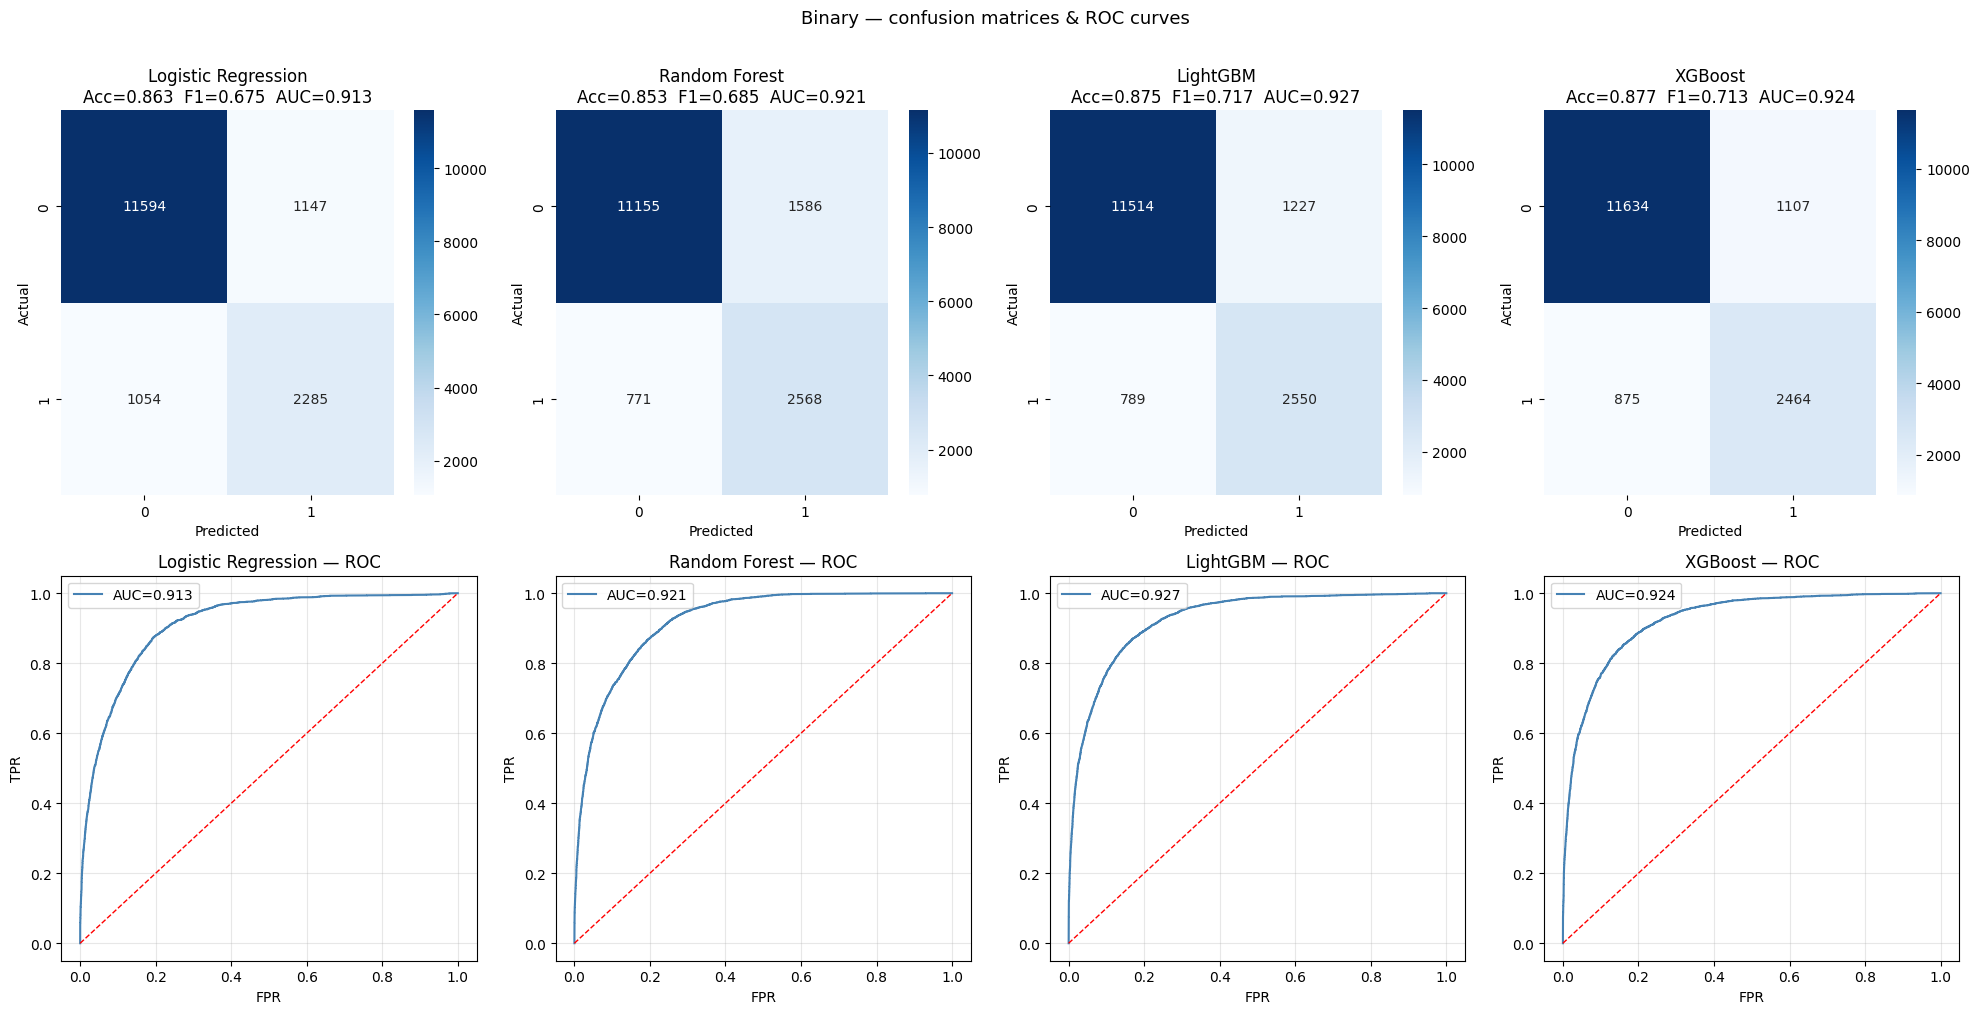

In [45]:
def plot_confusion(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)


n_models = len(results_bin)
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 10))

for col, (name, res) in enumerate(results_bin.items()):
    plot_confusion(
        y_test_bin, res["y_pred"], labels=[0, 1],
        title=f"{name}\nAcc={res['acc']:.3f}  F1={res['f1']:.3f}  AUC={res['auc']:.3f}",
        ax=axes[0, col],
    )
    ax = axes[1, col]
    if res["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test_bin, res["y_proba"])
        ax.plot(fpr, tpr, color="steelblue", linewidth=1.5,
                label=f"AUC={res['auc']:.3f}")
        ax.plot([0, 1], [0, 1], "r--", linewidth=1)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(f"{name} — ROC")
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.axis("off")

plt.suptitle("Binary — confusion matrices & ROC curves", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plot_cls_02_binary_eval.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Evaluation — 3-class (confusion matrices + reports)

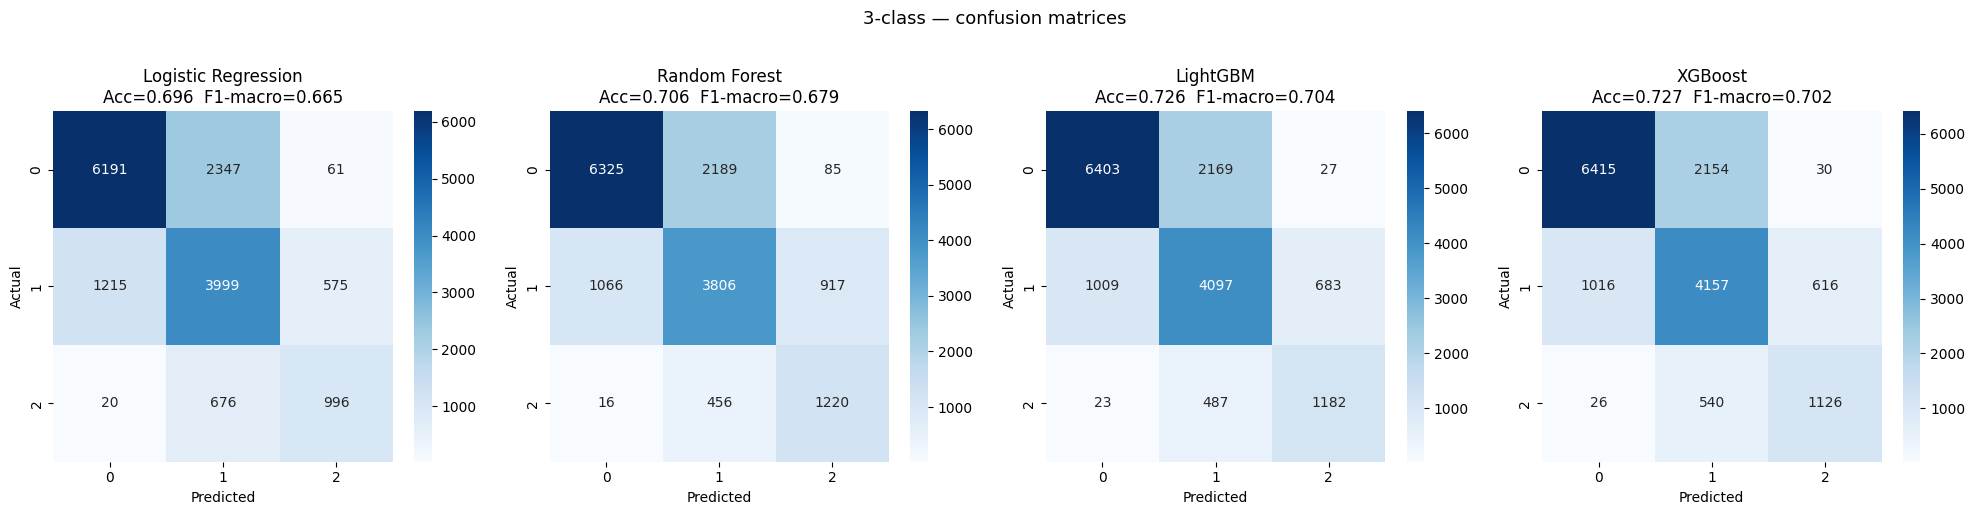


-- Logistic Regression --
              precision    recall  f1-score   support

         Low       0.83      0.72      0.77      8599
    Moderate       0.57      0.69      0.62      5789
        High       0.61      0.59      0.60      1692

    accuracy                           0.70     16080
   macro avg       0.67      0.67      0.67     16080
weighted avg       0.72      0.70      0.70     16080


-- Random Forest --
              precision    recall  f1-score   support

         Low       0.85      0.74      0.79      8599
    Moderate       0.59      0.66      0.62      5789
        High       0.55      0.72      0.62      1692

    accuracy                           0.71     16080
   macro avg       0.66      0.70      0.68     16080
weighted avg       0.73      0.71      0.71     16080


-- LightGBM --
              precision    recall  f1-score   support

         Low       0.86      0.74      0.80      8599
    Moderate       0.61      0.71      0.65      5789
        Hig

In [47]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
for col, (name, res) in enumerate(results_3.items()):
    plot_confusion(
        y_test_3, 
        res["y_pred"], 
        labels=[0, 1, 2],  # <--- Zmieniamy na indeksy numeryczne
        title=f"{name}\nAcc={res['acc']:.3f}  F1-macro={res['f1']:.3f}",
        ax=axes[col],
    )
plt.suptitle("3-class — confusion matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plot_cls_03_3class_eval.png", dpi=150, bbox_inches="tight")
plt.show()

for name, res in results_3.items():
    print(f"\n-- {name} --")
    # Tutaj mapujemy liczby z powrotem na nazwy w raporcie
    print(classification_report(y_test_3, res["y_pred"], 
                                target_names=CLASS_LABELS))


## 10. Metrics comparison

Binary classification -- test metrics:
                     Accuracy      F1     AUC  CV_AUC
model                                                
Logistic Regression    0.8631  0.6749  0.9130  0.8217
Random Forest          0.8534  0.6854  0.9207  0.8092
LightGBM               0.8746  0.7167  0.9274  0.8414
XGBoost                0.8767  0.7132  0.9240  0.8311

3-class classification -- test metrics:
                     Accuracy  F1_macro   CV_F1
model                                          
Logistic Regression    0.6956    0.6654  0.5383
Random Forest          0.7059    0.6785  0.5385
LightGBM               0.7265    0.7039  0.5605
XGBoost                0.7275    0.7023  0.5538


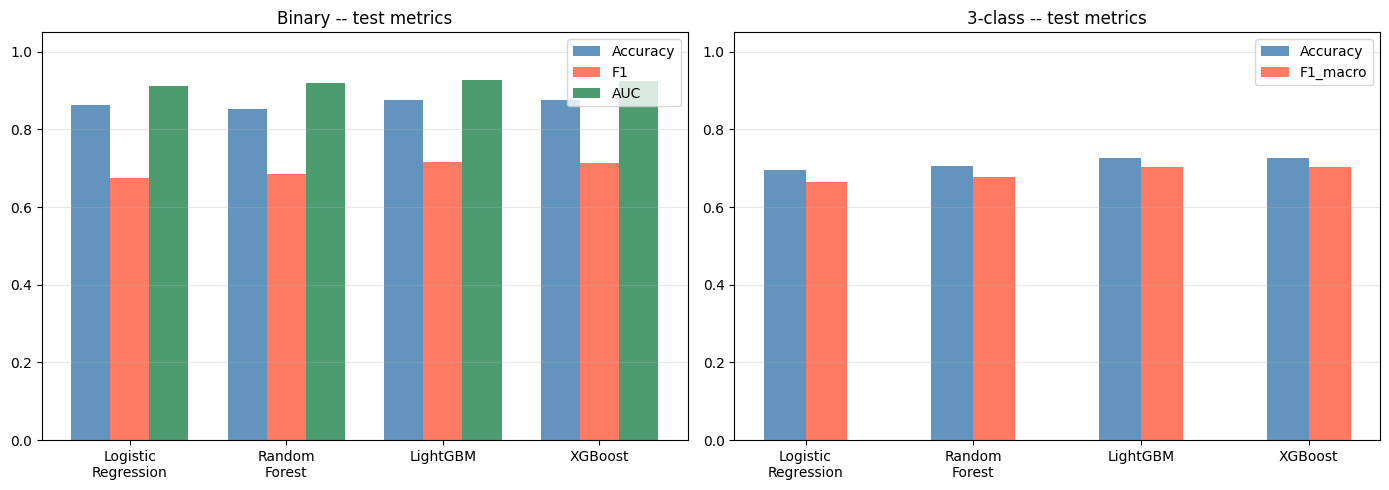

In [48]:
df_bin_metrics = pd.DataFrame([
    {"model": n, "Accuracy": r["acc"], "F1": r["f1"],
     "AUC": r["auc"], "CV_AUC": r["cv_score"]}
    for n, r in results_bin.items()
]).set_index("model")

df_3_metrics = pd.DataFrame([
    {"model": n, "Accuracy": r["acc"], "F1_macro": r["f1"],
     "CV_F1": r["cv_score"]}
    for n, r in results_3.items()
]).set_index("model")

print("Binary classification -- test metrics:")
print(df_bin_metrics.round(4).to_string())
print()
print("3-class classification -- test metrics:")
print(df_3_metrics.round(4).to_string())

model_names = list(results_bin.keys())
x = np.arange(len(model_names))
w = 0.25
colors = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, metric in enumerate(["Accuracy", "F1", "AUC"]):
    vals = [df_bin_metrics.loc[m, metric] for m in model_names]
    ax.bar(x + i * w, vals, w, label=metric, color=colors[i], alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels([m.replace(" ", "\n") for m in model_names])
ax.set_ylim(0, 1.05)
ax.set_title("Binary -- test metrics")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
for i, metric in enumerate(["Accuracy", "F1_macro"]):
    vals = [df_3_metrics.loc[m, metric] for m in model_names]
    ax.bar(x + i * w, vals, w, label=metric, color=colors[i], alpha=0.85)
ax.set_xticks(x + w / 2)
ax.set_xticklabels([m.replace(" ", "\n") for m in model_names])
ax.set_ylim(0, 1.05)
ax.set_title("3-class -- test metrics")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plot_cls_04_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Feature importance (tree models)

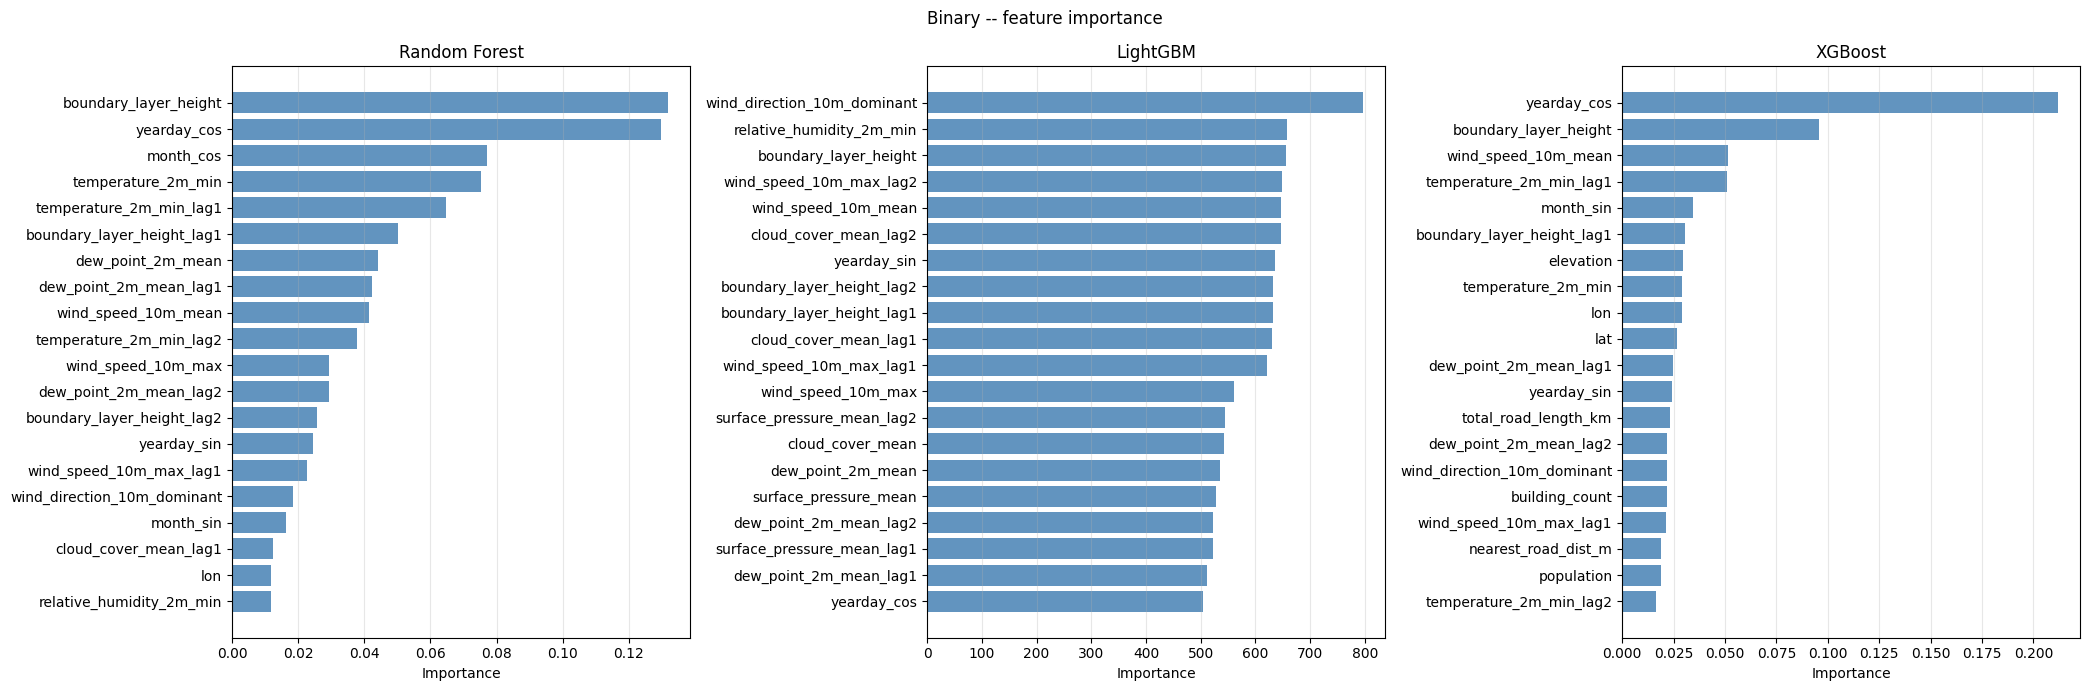

Saved plot_cls_05A_feature_importance_binary.png


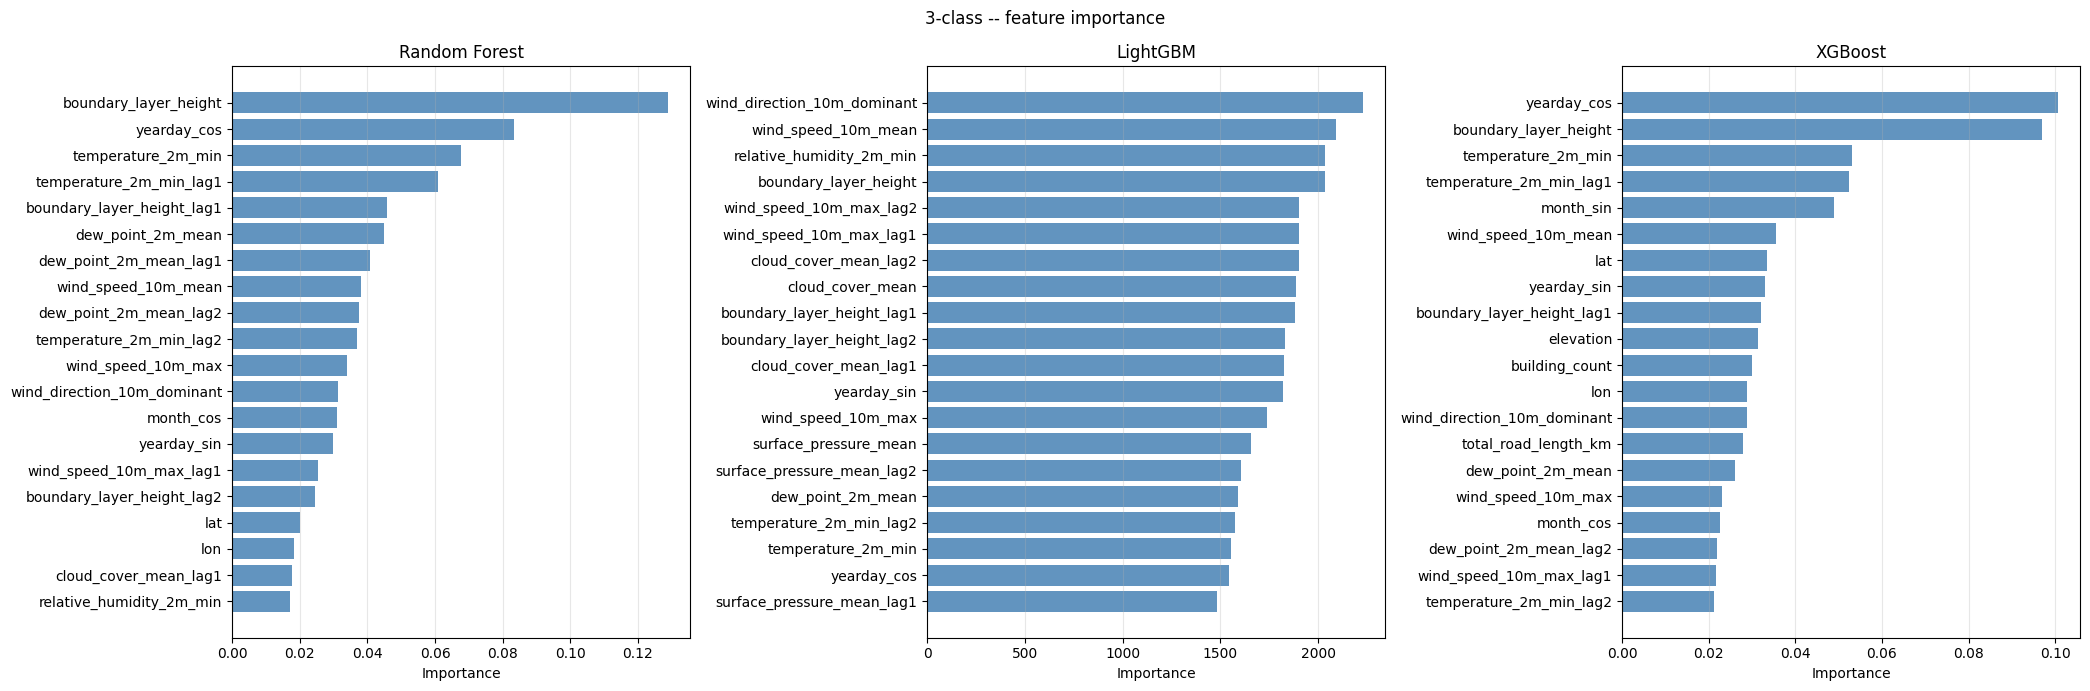

Saved plot_cls_05B_feature_importance_3class.png


In [49]:
def plot_feature_importance(searches, title, feature_names, save_path, top_n=20):
    tree_models = {n: s for n, s in searches.items() if n != "Logistic Regression"}
    n = len(tree_models)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (name, search) in zip(axes, tree_models.items()):
        importances = search.best_estimator_.named_steps["model"].feature_importances_
        idx = np.argsort(importances)[-top_n:]
        ax.barh(np.array(feature_names)[idx], importances[idx],
                color="steelblue", alpha=0.85)
        ax.set_xlabel("Importance")
        ax.set_title(name)
        ax.grid(True, alpha=0.3, axis="x")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")


plot_feature_importance(searches_bin, "Binary -- feature importance",
                        FEATURE_COLS, "plot_cls_05A_feature_importance_binary.png")
plot_feature_importance(searches_3,   "3-class -- feature importance",
                        FEATURE_COLS, "plot_cls_05B_feature_importance_3class.png")


## 12. Logistic Regression — coefficients

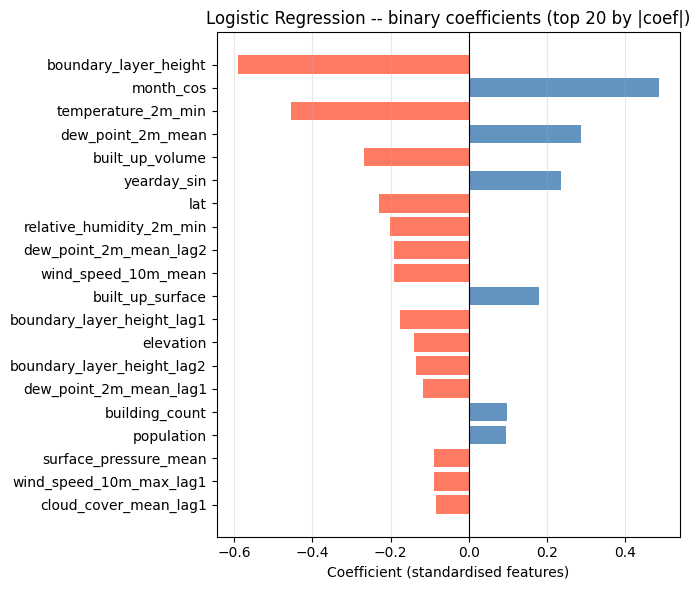

In [50]:
lr_bin = searches_bin["Logistic Regression"].best_estimator_.named_steps["model"]
coef   = lr_bin.coef_[0]
idx    = np.argsort(np.abs(coef))[-20:]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(np.array(FEATURE_COLS)[idx], coef[idx],
        color=["tomato" if c < 0 else "steelblue" for c in coef[idx]], alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardised features)")
ax.set_title("Logistic Regression -- binary coefficients (top 20 by |coef|)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("plot_cls_06_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Summary

In [51]:
best_bin = df_bin_metrics["AUC"].idxmax()
best_3   = df_3_metrics["F1_macro"].idxmax()

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Data         : all_data.csv ({df_raw['stacja'].nunique()} stations)")
print(f"Train        : {min(TRAIN_YEARS)}-{max(TRAIN_YEARS)} ({len(train):,} samples)")
print(f"Test         : {TEST_YEAR} ({len(test):,} samples)")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"CV strategy  : TimeSeriesSplit, {N_CV_SPLITS} folds")
print(f"Search iters : {N_ITER_SEARCH} per model")
print()
print("-- Binary (PM2.5 > 25 ug/m3)  [CV: AUC] --")
print(df_bin_metrics.round(4).to_string())
print(f"Best (AUC): {best_bin}")
print()
print("-- 3-class (Low/Moderate/High)  [CV: F1-macro] --")
print(df_3_metrics.round(4).to_string())
print(f"Best (F1-macro): {best_3}")
print()
print("Saved plots:")
for p in [
    "plot_cls_01_class_distribution.png",
    "plot_cls_02_binary_eval.png",
    "plot_cls_03_3class_eval.png",
    "plot_cls_04_metrics_comparison.png",
    "plot_cls_05A_feature_importance_binary.png",
    "plot_cls_05B_feature_importance_3class.png",
    "plot_cls_06_lr_coefficients.png",
]:
    print(f"  {p}")


SUMMARY
Data         : all_data.csv (45 stations)
Train        : 2016-2018 (31,847 samples)
Test         : 2019 (16,080 samples)
Features     : 34
CV strategy  : TimeSeriesSplit, 5 folds
Search iters : 1 per model

-- Binary (PM2.5 > 25 ug/m3)  [CV: AUC] --
                     Accuracy      F1     AUC  CV_AUC
model                                                
Logistic Regression    0.8631  0.6749  0.9130  0.8217
Random Forest          0.8534  0.6854  0.9207  0.8092
LightGBM               0.8746  0.7167  0.9274  0.8414
XGBoost                0.8767  0.7132  0.9240  0.8311
Best (AUC): LightGBM

-- 3-class (Low/Moderate/High)  [CV: F1-macro] --
                     Accuracy  F1_macro   CV_F1
model                                          
Logistic Regression    0.6956    0.6654  0.5383
Random Forest          0.7059    0.6785  0.5385
LightGBM               0.7265    0.7039  0.5605
XGBoost                0.7275    0.7023  0.5538
Best (F1-macro): LightGBM

Saved plots:
  plot_cls_01_clas